# Gold Basis: GC=F Futures vs XAUUSD Spot
Loads spot data from your CSV, fetches GC=F from Yahoo Finance, and plots the basis.

In [2]:
%matplotlib inline
import sys, os
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

## Config

In [5]:
# ── Edit these as needed ──────────────────────────────────────────────────────
CSV_PATH       = "data.csv"   # path to your CSV file
FUTURES_TICKER = "GC=F"
# ─────────────────────────────────────────────────────────────────────────────

## Load Spot Data from CSV

In [6]:
spot_df = pd.read_csv(
    CSV_PATH,
    thousands=",",        # handle "4,219.32" -> 4219.32
    encoding="utf-8-sig", # strip BOM if present
)
spot_df.columns = spot_df.columns.str.strip().str.replace('"', '')
spot_df["Date"] = pd.to_datetime(spot_df["Date"], format="%m/%d/%Y")
spot_df = spot_df.set_index("Date").sort_index()

xau = spot_df["Price"].astype(float)

print(f"Rows  : {len(xau)}")
print(f"Range : {xau.index[0].date()} to {xau.index[-1].date()}")
print(f"Price : ${xau.min():.2f} - ${xau.max():.2f}")

Rows  : 118
Range : 2026-01-01 to 2026-06-12
Price : $4075.08 - $5400.25


## Download Futures from Yahoo Finance

In [7]:
start = xau.index[0].strftime("%Y-%m-%d")
end   = (xau.index[-1] + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

print(f"Downloading {FUTURES_TICKER}  ({start} to {end}) ...")
raw = yf.download(FUTURES_TICKER, start=start, end=end, auto_adjust=True, progress=False)

if raw.empty:
    raise RuntimeError(f"No data returned for '{FUTURES_TICKER}'. Check your connection.")

gc = raw["Close"].squeeze()
gc.index = pd.to_datetime(gc.index)
print(f"Downloaded {len(gc)} bars")

Downloaded 112 bars


## Compute Basis

In [8]:
df = pd.DataFrame({"GC_F": gc, "XAUUSD": xau}).dropna()
df["Basis"]     = df["GC_F"] - df["XAUUSD"]
df["Basis_pct"] = (df["Basis"] / df["XAUUSD"]) * 100

print(f"Overlapping bars : {len(df)}  ({df.index[0].date()} to {df.index[-1].date()})")
print()
print("Basis summary (GC=F - XAUUSD):")
df["Basis"].describe().round(4)

Overlapping bars : 112  (2026-01-02 to 2026-06-12)

Basis summary (GC=F - XAUUSD):


count    112.0000
mean      -6.5799
std       34.8411
min     -151.4501
25%      -16.1101
50%       -4.4650
75%        8.9125
max       90.4499
Name: Basis, dtype: float64

## Plot

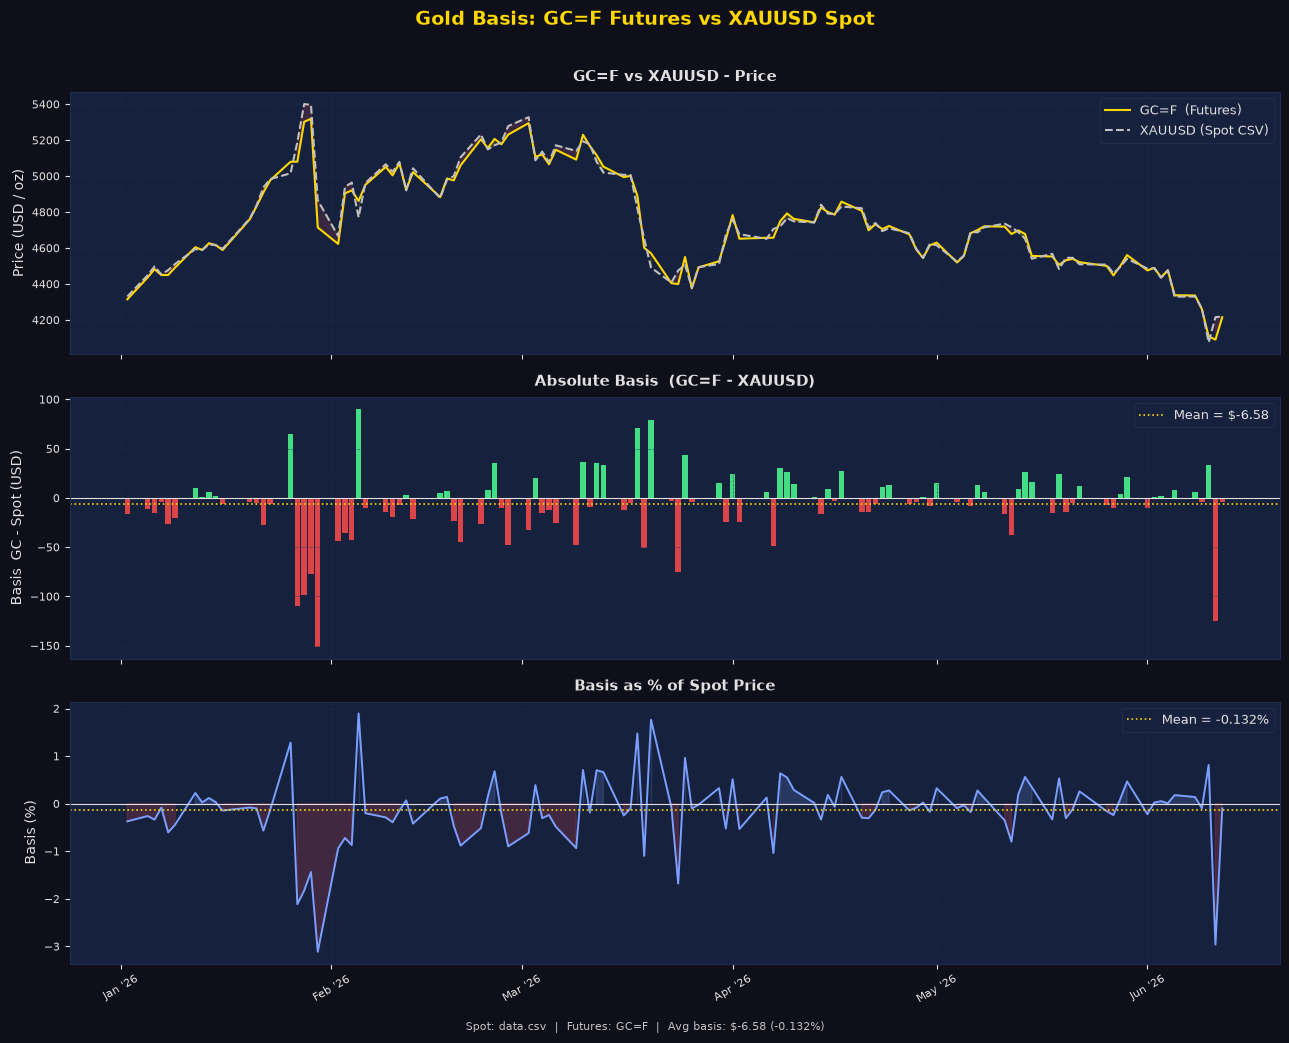

In [9]:
GOLD, SILVER = "#FFD700", "#C0C0C0"
RED,  GREEN  = "#FF4C4C", "#4CFF91"
BG, PANEL, GRID, TEXT = "#0f0f1a", "#16213e", "#1f2d50", "#e0e0e0"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT, fontsize=11, fontweight="bold", pad=8)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.yaxis.label.set_color(TEXT)
    ax.spines[:].set_color(GRID)
    ax.grid(color=GRID, linewidth=0.5, linestyle="--", alpha=0.7)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor(BG)

# Panel 1 — Prices
ax1 = axes[0]
ax1.plot(df.index, df["GC_F"],   color=GOLD,   lw=1.5, label="GC=F  (Futures)")
ax1.plot(df.index, df["XAUUSD"], color=SILVER, lw=1.5, linestyle="--", label="XAUUSD (Spot CSV)")
ax1.fill_between(df.index, df["GC_F"], df["XAUUSD"], where=df["GC_F"] >= df["XAUUSD"], alpha=0.15, color=GOLD)
ax1.fill_between(df.index, df["GC_F"], df["XAUUSD"], where=df["GC_F"] <  df["XAUUSD"], alpha=0.15, color=RED)
ax1.set_ylabel("Price (USD / oz)", color=TEXT)
ax1.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
style_ax(ax1, "GC=F vs XAUUSD - Price")

# Panel 2 — Absolute basis
ax2 = axes[1]
bar_colors = np.where(df["Basis"] >= 0, GREEN, RED)
ax2.bar(df.index, df["Basis"], color=bar_colors, width=0.8, alpha=0.85)
ax2.axhline(0, color=TEXT, lw=0.8)
ax2.axhline(df["Basis"].mean(), color=GOLD, lw=1.2, linestyle=":", label=f"Mean = ${df['Basis'].mean():.2f}")
ax2.set_ylabel("Basis  GC - Spot (USD)", color=TEXT)
ax2.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
style_ax(ax2, "Absolute Basis  (GC=F - XAUUSD)")

# Panel 3 — % basis
ax3 = axes[2]
ax3.plot(df.index, df["Basis_pct"], color="#7B9FFF", lw=1.4)
ax3.fill_between(df.index, df["Basis_pct"], 0, where=df["Basis_pct"] >= 0, alpha=0.18, color="#7B9FFF")
ax3.fill_between(df.index, df["Basis_pct"], 0, where=df["Basis_pct"] <  0, alpha=0.18, color=RED)
ax3.axhline(0, color=TEXT, lw=0.8)
ax3.axhline(df["Basis_pct"].mean(), color=GOLD, lw=1.2, linestyle=":", label=f"Mean = {df['Basis_pct'].mean():.3f}%")
ax3.set_ylabel("Basis (%)", color=TEXT)
ax3.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=9)
style_ax(ax3, "Basis as % of Spot Price")

ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax3.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30, color=TEXT, fontsize=8)

fig.suptitle("Gold Basis: GC=F Futures vs XAUUSD Spot", color=GOLD, fontsize=14, fontweight="bold", y=1.01)
fig.text(0.5, -0.01,
         f"Spot: {os.path.basename(CSV_PATH)}  |  Futures: {FUTURES_TICKER}  |  "
         f"Avg basis: ${df['Basis'].mean():.2f} ({df['Basis_pct'].mean():.3f}%)",
         ha="center", color=SILVER, fontsize=8)

plt.tight_layout()
plt.savefig("gold_basis.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()